summary_results架構:<br>
資料前處理（準備丟入model的Ｘand Y)
1. Without Feature Selection and SMOTE
   - LR (Benchmark) 1
2. Without Feature Selection but with SMOTE
   - LR  2
   - XGB 3
   - SVM 4
   - RF  5
3. SMOTE + Feature Selection with LASSO
   - LR  6
   - XGB 7
   - SVM 8
   - RF  9
4. SMOTE + Feature Selection with XGB
   - LR  10
   - XGB 11
   - SVM 12
   - RF  13

In [2]:
import sys
print(sys.version)

3.7.3 (v3.7.3:ef4ec6ed12, Mar 25 2019, 16:52:21) 
[Clang 6.0 (clang-600.0.57)]


In [3]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None) 

In [55]:
df = pd.read_csv('clean_data.csv', low_memory=False)

In [56]:
# 方法1: 選取所有非數值型的欄位
# np.number 包含了所有數值型別 (int, float, complex)
non_numeric_cols_df = df.select_dtypes(exclude=np.number)

# 如果您想排除更廣泛的類型，例如也排除布林值和日期時間，可以這樣做：
# non_numeric_cols_df = df.select_dtypes(exclude=['number', 'bool', 'datetime'])

print("非數值型的 DataFrame：")
print(non_numeric_cols_df)
print("-" * 30)

print("非數值型欄位的名稱：")
print(non_numeric_cols_df.columns.tolist())

非數值型的 DataFrame：
         datadate   tic                         conm delist date
0      2019-05-31   AIR                     AAR CORP         NaN
1      2020-05-31   AIR                     AAR CORP         NaN
2      2021-05-31   AIR                     AAR CORP         NaN
3      2022-05-31   AIR                     AAR CORP         NaN
4      2023-05-31   AIR                     AAR CORP         NaN
...           ...   ...                          ...         ...
56736  2024-12-31  INDP    INDAPTUS THERAPEUTICS INC         NaN
56737  2023-12-31  BEMB  ISHARES JP MORGAN B U E M B         NaN
56738  2024-12-31  BEMB  ISHARES JP MORGAN B U E M B         NaN
56739  2023-12-31   TIC                  ACUREN CORP         NaN
56740  2024-12-31   TIC                  ACUREN CORP         NaN

[56741 rows x 4 columns]
------------------------------
非數值型欄位的名稱：
['datadate', 'tic', 'conm', 'delist date']


In [57]:
# 跑 LR前先 drop 非數值的欄位
# 移除和 delist 相關的欄位以免透露給模型非財務資訊：'conm','sic_rank','dummy_PERMNO_missing',
 #              'dummy_delist date_missing','dummy_delist year_missing'
exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank','dummy_PERMNO_missing',
              'dummy_delist date_missing','dummy_delist year_missing']
#exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank']
data=df.drop(exclude_list,axis=1)

# 按時間分測試集2024和訓練集2019-2023
X = data.drop(columns=['dummy_delistconm'])# 特徵欄位 測試集2024
y = data['dummy_delistconm']

# 根據年代分割
X_train = X[data['year'].between(2019, 2023)]
y_train = y[data['year'].between(2019, 2023)]

X_test = X[data['year'] == 2024]
y_test = y[data['year'] == 2024]

# 確認分割結果
print("訓練集大小:", X_train.shape, "測試集大小:", X_test.shape)

訓練集大小: (46960, 278) 測試集大小: (9781, 278)


In [58]:
#用 中位數""補 missing value
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<h3>1.Without Feature Selection and SMOTE</h3> 

In [60]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'logistic_regression_model_A_Without Feature Selection and SMOTE.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 logistic_regression_model_A_Without Feature Selection and SMOTE.joblib 載入。


準確度: 0.9986708925467743
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.40      0.17      0.24        12

    accuracy                           1.00      9781
   macro avg       0.70      0.58      0.62      9781
weighted avg       1.00      1.00      1.00      9781



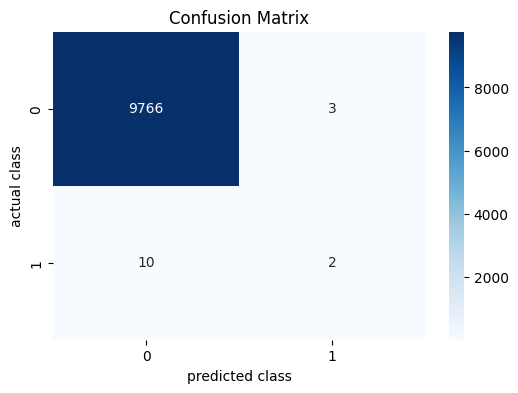

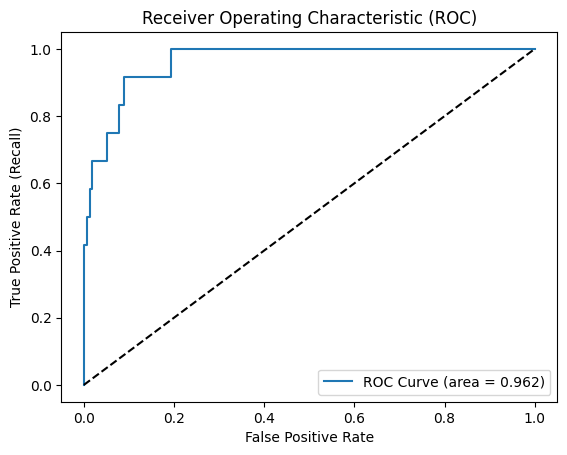

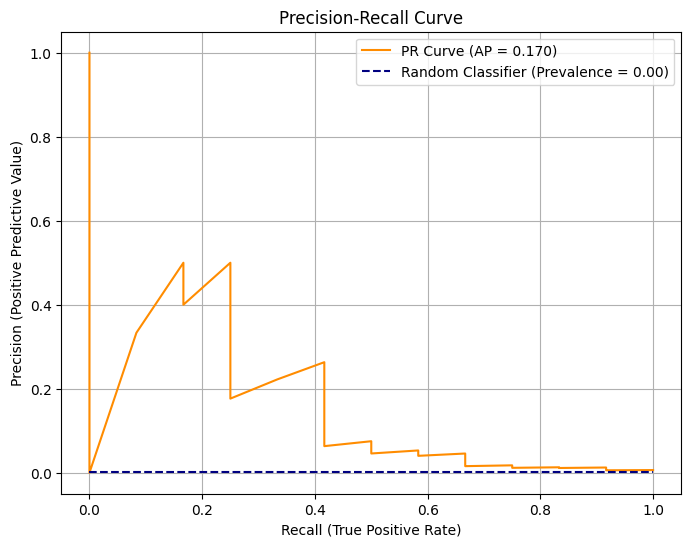

Average Precision (AP) Score: 0.170


In [61]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model.predict(X_test_scaled)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_1 = loaded_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_1)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_1)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_1)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_1)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h3>2. Without Feature Selection but with SMOTE</h3>

In [62]:
from collections import Counter
from imblearn.over_sampling import SMOTE
print("Before SMOTE:", Counter(y_train))
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_res))

Before SMOTE: Counter({0: 46742, 1: 218})
After SMOTE: Counter({0: 46742, 1: 46742})


In [63]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

<h4>LR</h4>

In [64]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'logistic_regression_model_B_Without Feature Selection but with SMOTE.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 logistic_regression_model_B_Without Feature Selection but with SMOTE.joblib 載入。


準確度: 0.9844596667007464
分類報告:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      9769
           1       0.05      0.58      0.08        12

    accuracy                           0.98      9781
   macro avg       0.52      0.78      0.54      9781
weighted avg       1.00      0.98      0.99      9781



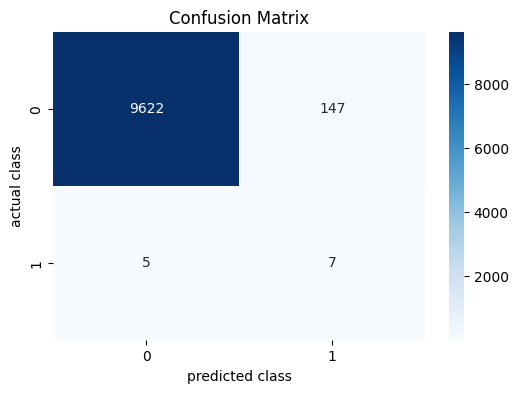

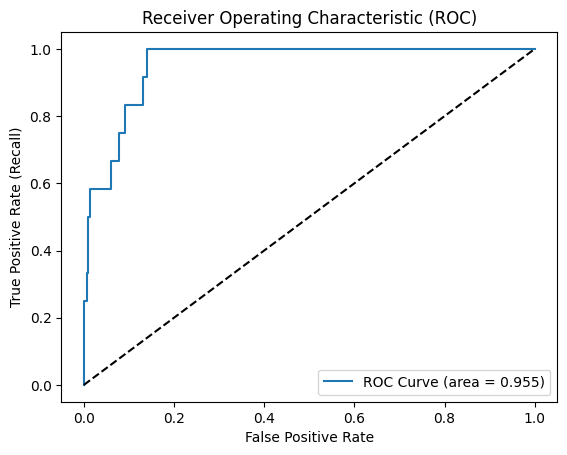

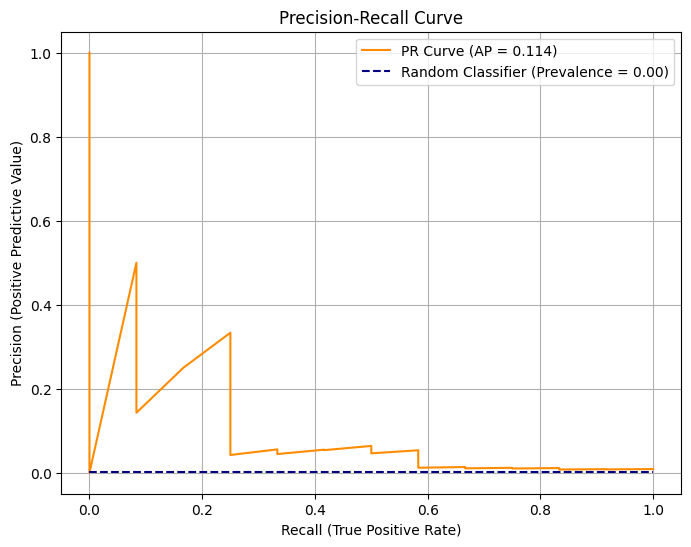

Average Precision (AP) Score: 0.114


In [65]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model.predict(X_test_scaled)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_2 = loaded_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_2)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_2)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_2)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_2)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>XGB</h4>

In [66]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'withoutfeature_selection_xgb_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 withoutfeature_selection_xgb_model.joblib 載入。


準確度: 0.9979552193027298
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.28      0.42      0.33        12

    accuracy                           1.00      9781
   macro avg       0.64      0.71      0.67      9781
weighted avg       1.00      1.00      1.00      9781



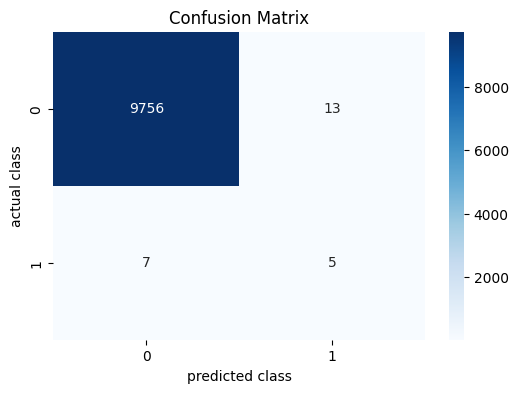

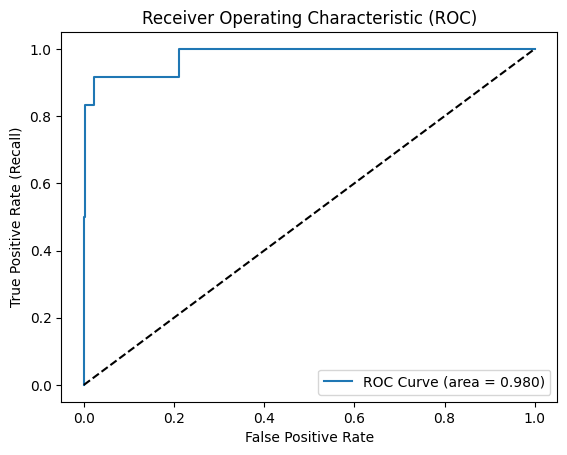

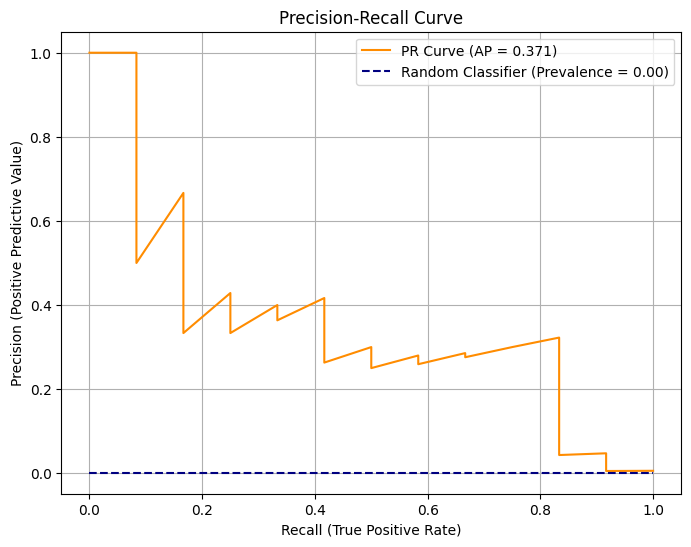

Average Precision (AP) Score: 0.371


In [67]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model.predict(X_test_scaled)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_3 = loaded_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_3)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_3)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_3)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_3)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>SVM</h4>

In [68]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'withoutfeature_selection_svm_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 withoutfeature_selection_svm_model.joblib 載入。


準確度: 0.9944790921173704
分類報告:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      9769
           1       0.16      0.83      0.27        12

    accuracy                           0.99      9781
   macro avg       0.58      0.91      0.63      9781
weighted avg       1.00      0.99      1.00      9781



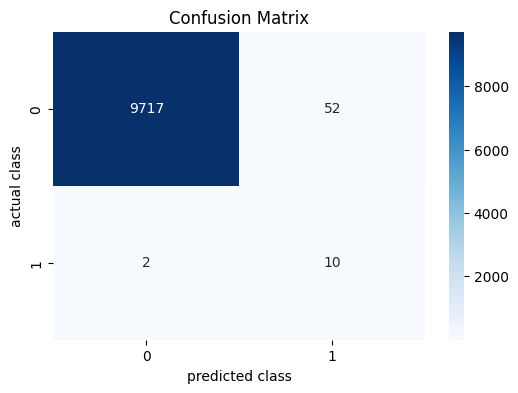

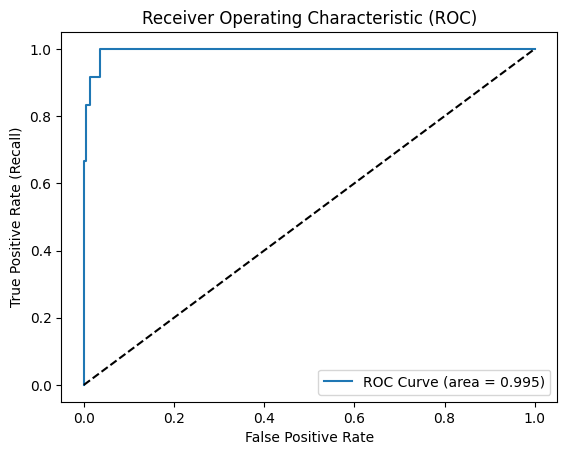

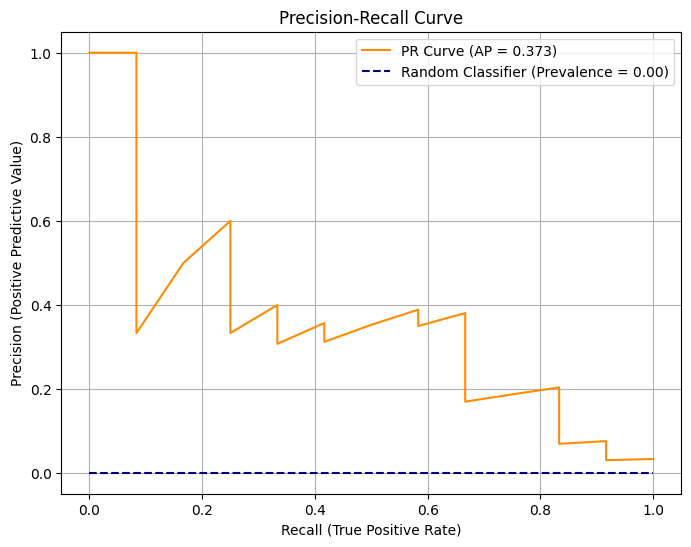

Average Precision (AP) Score: 0.373


In [69]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model.predict(X_test_scaled)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_4 = loaded_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_4)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_4)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_4)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_4)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>RF</h4>

In [70]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'withoutfeature_selection_rf_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 withoutfeature_selection_rf_model.joblib 載入。


準確度: 0.9852775789796544
分類報告:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      9769
           1       0.01      0.17      0.03        12

    accuracy                           0.99      9781
   macro avg       0.51      0.58      0.51      9781
weighted avg       1.00      0.99      0.99      9781



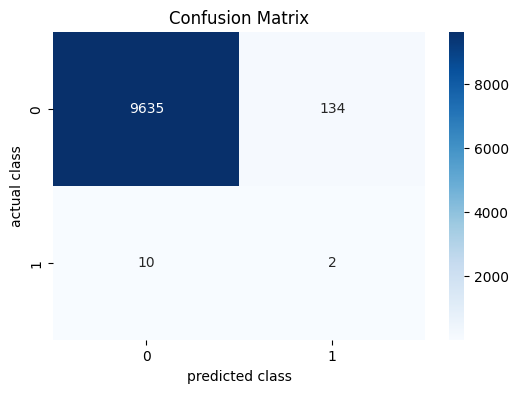

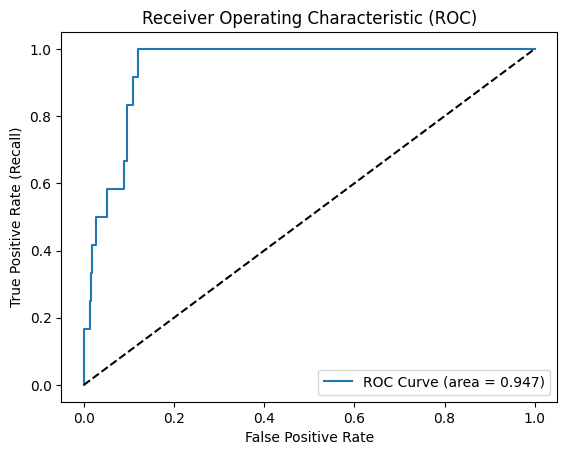

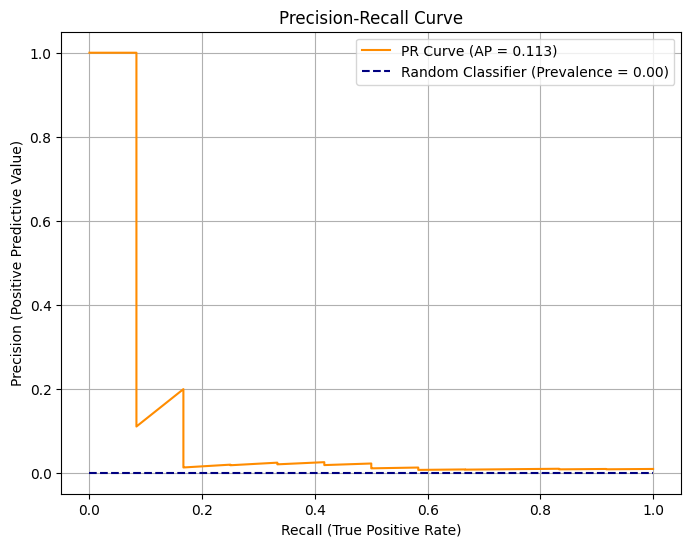

Average Precision (AP) Score: 0.113


In [71]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model.predict(X_test_scaled)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_5 = loaded_model.predict_proba(X_test_scaled)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_5)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_5)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_5)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_5)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h3>3. SMOTE+Feature Selection with LASSO</h3>

In [25]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

In [26]:
# --- 重新載入 lasso_selector ---
lasso_selector = joblib.load('lasso_feature_selector.joblib')
print("Lasso selector 載入成功。")

# retain features with nonzero coefficients
selected_mask = lasso_selector.coef_[0] != 0
selected_features = X.columns[selected_mask]
print(f"Selected features ({len(selected_features)}): {list(selected_features)}")

# reduce data
X_res_selected = X_res_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]

Lasso selector 載入成功。
Selected features (129): ['dummy_costat', 'aco', 'act', 'artfs', 'ceq', 'dlc', 'dltt', 'dptc', 'esopt', 'ialti', 'icapt', 'intan', 'invt', 'ivpt', 'ivst', 'lco', 'lcuacu', 'npat', 'pvt', 'rect', 'ret', 'rvdt', 'rveqt', 'dvt', 'idit', 'revt', 'uopi', 'xint', 'xlr', 'xopr', 'year', 'dummy_delist', 'dummy_100', 'dummy_200', 'dummy_700', 'dummy_800', 'dummy_1000', 'dummy_1200', 'dummy_1300', 'dummy_1400', 'dummy_1500', 'dummy_1600', 'dummy_1700', 'dummy_2000', 'dummy_2100', 'dummy_2200', 'dummy_2300', 'dummy_2400', 'dummy_2500', 'dummy_2600', 'dummy_2700', 'dummy_2800', 'dummy_2900', 'dummy_3000', 'dummy_3100', 'dummy_3200', 'dummy_3300', 'dummy_3400', 'dummy_3500', 'dummy_3600', 'dummy_3700', 'dummy_3800', 'dummy_3900', 'dummy_4000', 'dummy_4100', 'dummy_4200', 'dummy_4400', 'dummy_4500', 'dummy_4600', 'dummy_4700', 'dummy_4800', 'dummy_4900', 'dummy_5000', 'dummy_5100', 'dummy_5300', 'dummy_5400', 'dummy_5500', 'dummy_5600', 'dummy_5700', 'dummy_5800', 'dummy_5900', 

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,


<h4>LR</h4>

In [37]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'logistic_regression_model_C_Feature Selection LASSO and with SMOTE.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_C = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 logistic_regression_model_C_Feature Selection LASSO and with SMOTE.joblib 載入。


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,


準確度: 0.9829260811777937
分類報告:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99      9769
           1       0.04      0.58      0.08        12

    accuracy                           0.98      9781
   macro avg       0.52      0.78      0.53      9781
weighted avg       1.00      0.98      0.99      9781



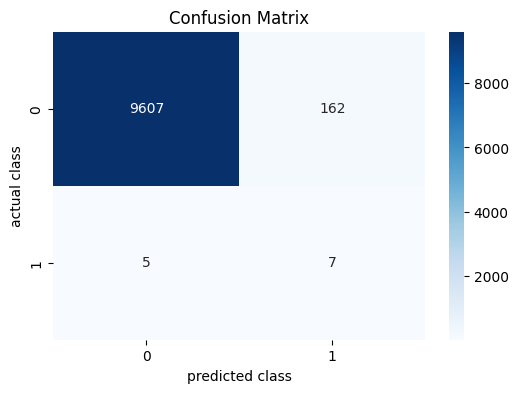

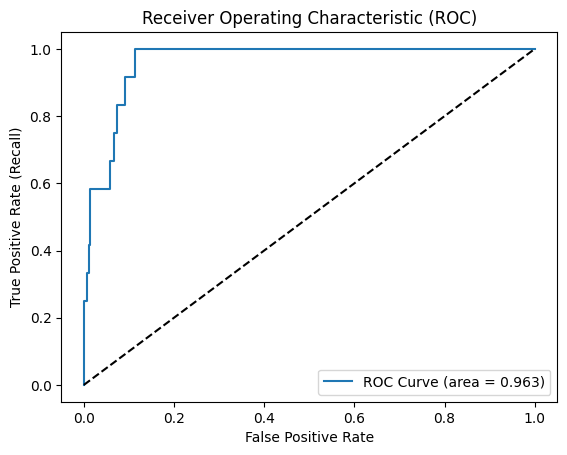

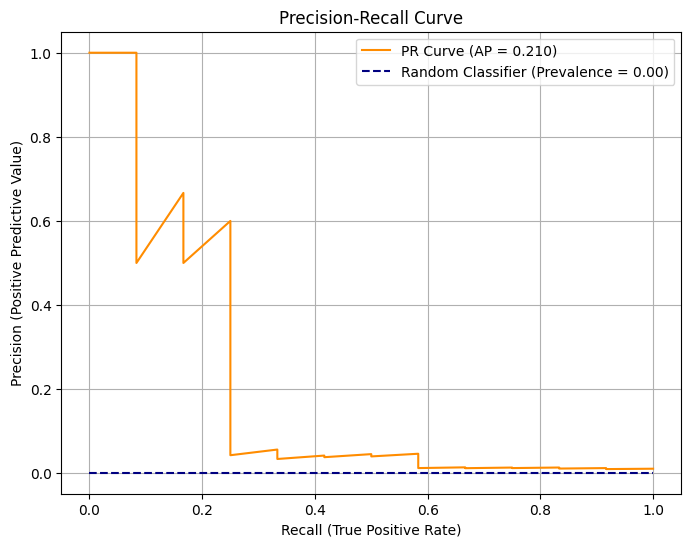

Average Precision (AP) Score: 0.210


In [38]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_C.predict(X_test_selected)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_6 = loaded_model_C.predict_proba(X_test_selected)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_6)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_6)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_6)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_6)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>XGB</h4>

In [39]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'feature_selection_lasso_xgb_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_C = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 feature_selection_lasso_xgb_model.joblib 載入。


準確度: 0.9981596973724568
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.36      0.67      0.47        12

    accuracy                           1.00      9781
   macro avg       0.68      0.83      0.73      9781
weighted avg       1.00      1.00      1.00      9781



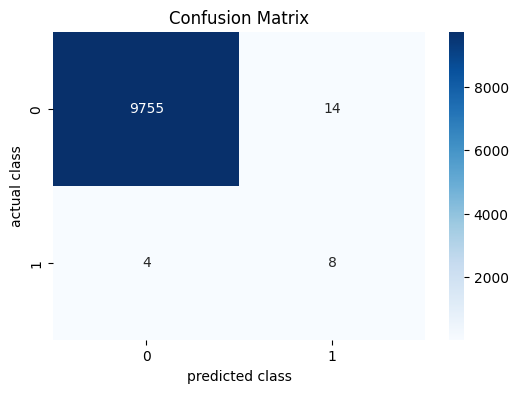

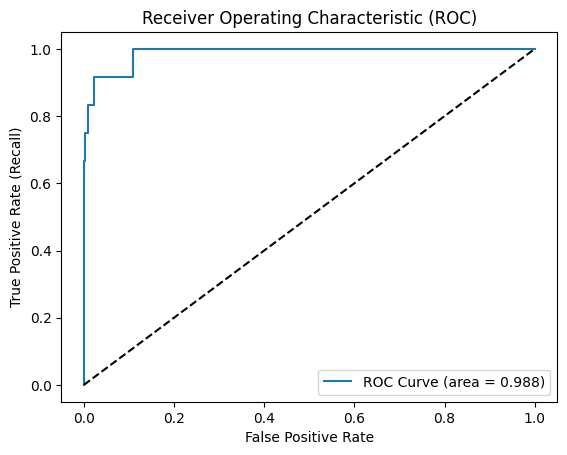

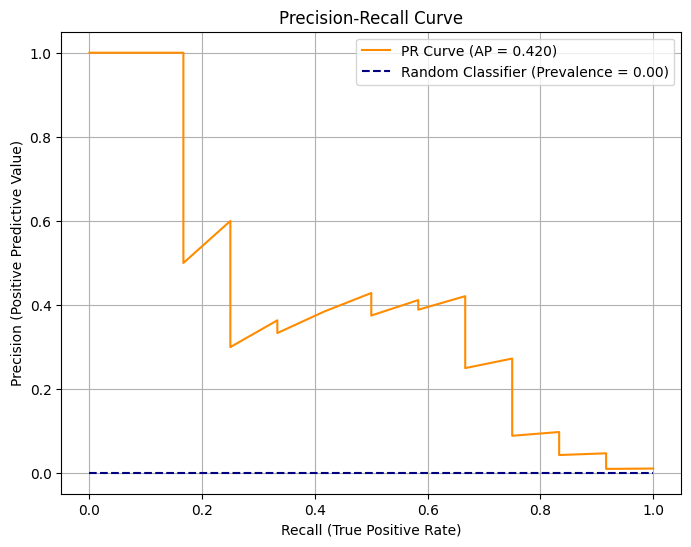

Average Precision (AP) Score: 0.420


In [40]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_C.predict(X_test_selected)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_7 = loaded_model_C.predict_proba(X_test_selected)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_7)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_7)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_7)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_7)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>SVM</h4>

In [41]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'feature_selection_lasso_svm_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_C = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 feature_selection_lasso_svm_model.joblib 載入。


準確度: 0.9953992434311421
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.18      0.75      0.29        12

    accuracy                           1.00      9781
   macro avg       0.59      0.87      0.64      9781
weighted avg       1.00      1.00      1.00      9781



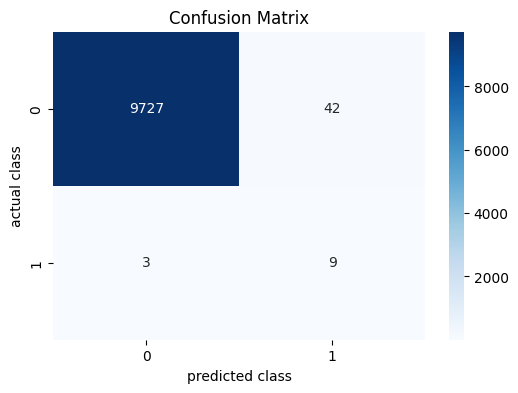

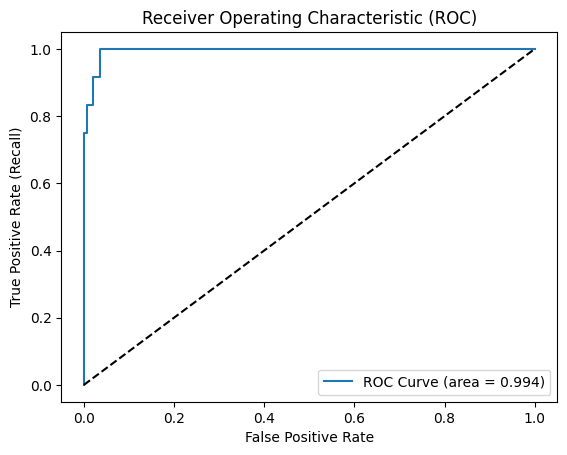

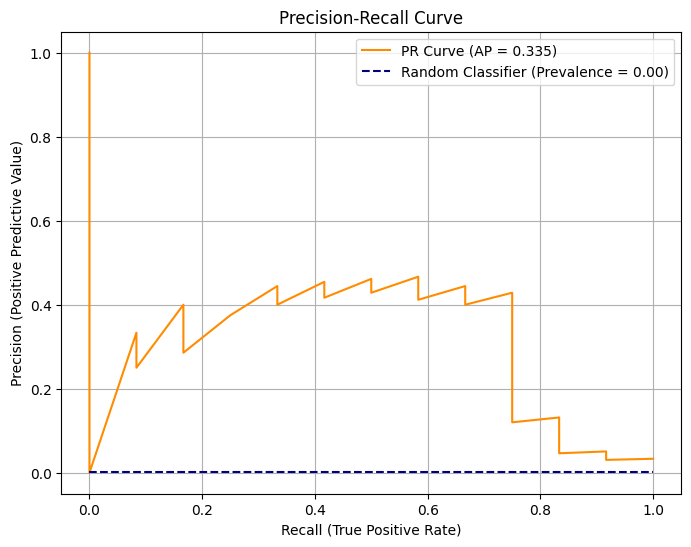

Average Precision (AP) Score: 0.335


In [42]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_C.predict(X_test_selected)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_8 = loaded_model_C.predict_proba(X_test_selected)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_8)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_8)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_8)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_8)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>RF</h4>

In [43]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'feature_selection_lasso_rf_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_C = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 feature_selection_lasso_rf_model.joblib 載入。


準確度: 0.9987731315816378
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.50      0.33      0.40        12

    accuracy                           1.00      9781
   macro avg       0.75      0.67      0.70      9781
weighted avg       1.00      1.00      1.00      9781



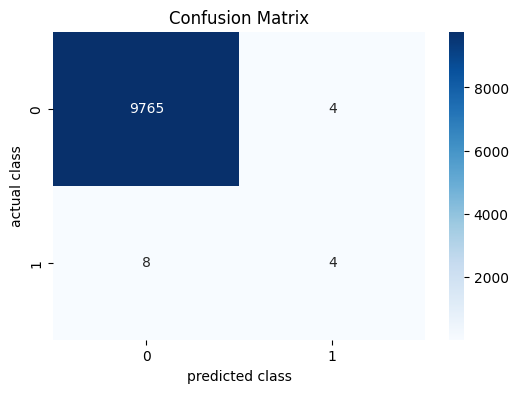

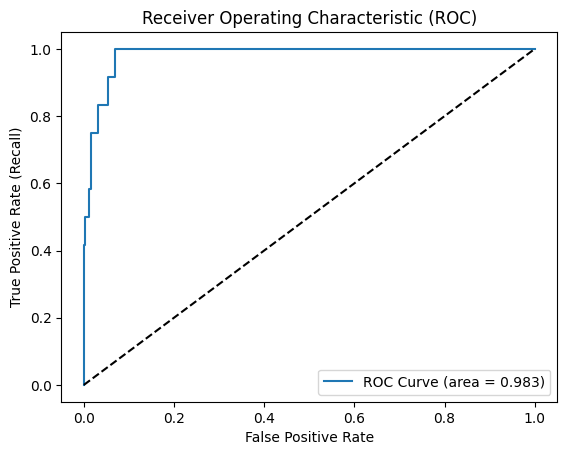

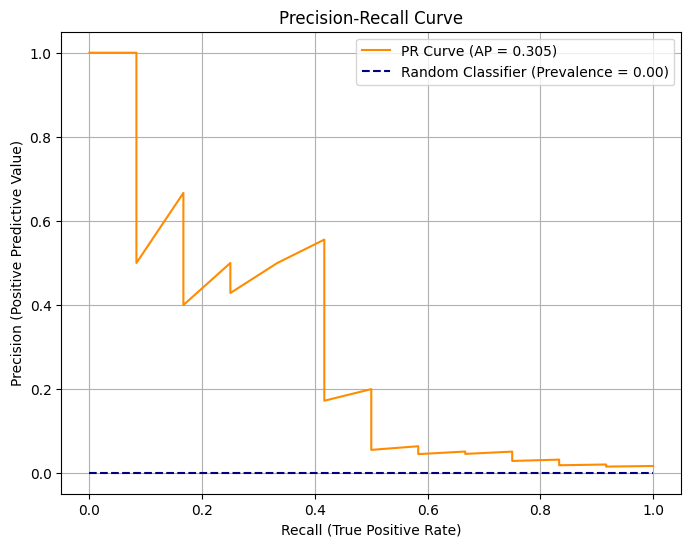

Average Precision (AP) Score: 0.305


In [44]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_C.predict(X_test_selected)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_9 = loaded_model_C.predict_proba(X_test_selected)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_9)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_9)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_9)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_9)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h3>4. SMOTE + Feature Selection with XGB</h3>

XGBoost selector (原生方法) 載入成功。

Feature Importances (Top 20):
                feature  importance
216  dummy_mrct_missing    0.218884
111          dummy_1300    0.046736
29                 ivpt    0.046420
180    dummy_at_missing    0.036113
68              citotal    0.034005
103                year    0.032749
178   dummy_act_missing    0.027334
164          dummy_7300    0.025612
22                intan    0.025234
161          dummy_6700    0.023491
30                 ivst    0.022529
0          dummy_costat    0.020810
87                 revt    0.019761
90                  txt    0.017812
97                 xopr    0.017082
8                   dlc    0.016801
6                   ceq    0.016503
21                icapt    0.015757
5                    at    0.015679
53                 rvdt    0.015233


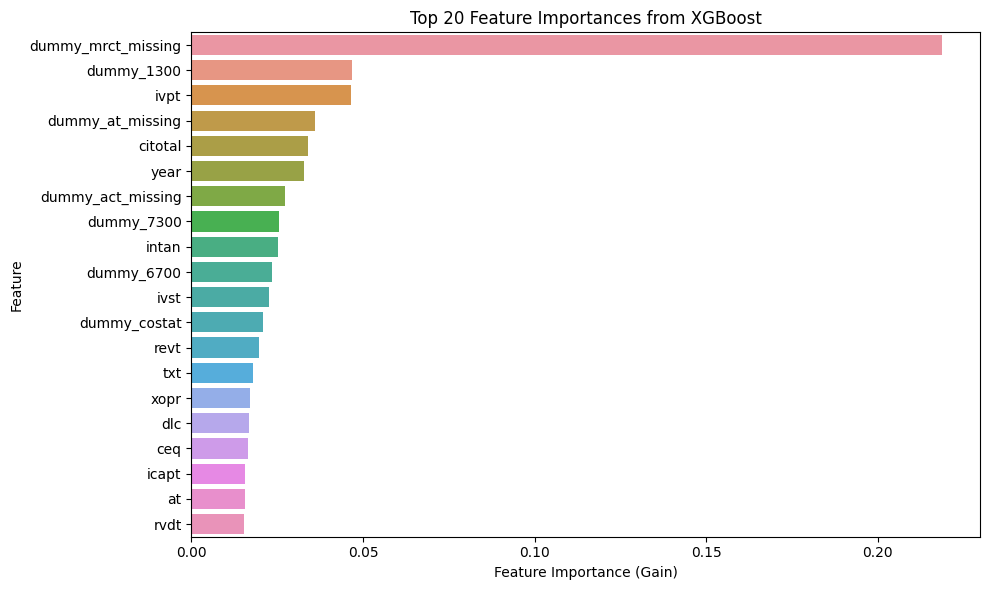


Number of features selected by XGBoost: 129
Selected features: ['dummy_mrct_missing', 'dummy_1300', 'ivpt', 'dummy_at_missing', 'citotal', 'year', 'dummy_act_missing', 'dummy_7300', 'intan', 'dummy_6700', 'ivst', 'dummy_costat', 'revt', 'txt', 'xopr', 'dlc', 'ceq', 'icapt', 'at', 'rvdt', 'tstk', 'dummy_2800', 'ppegt', 'xint', 'dummy_6000', 'pstk', 'dummy_3800', 'xagt', 'act', 'rect', 'dummy_delist', 'dummy_3600', 'xlr', 'dltt', 'dummy_invt_missing', 'txndb', 'dummy_xint_missing', 'lct', 'idit', 'aco', 'mrct', 'lo', 'dummy_3500', 'dvt', 'dummy_4800', 'dummy_4900', 'dummy_5800', 'ppent', 'dummy_5000', 'lt', 'dummy_7900', 'dummy_dptc_missing', 'dummy_8700', 'dummy_3400', 'dummy_4500', 'dummy_5200', 'dummy_5900', 'invt', 'lco', 'dummy_dltt_missing', 'dummy_aco_missing', 'dummy_istm_missing', 'dummy_7800', 'dummy_isut_missing', 'dummy_ivpt_missing', 'dummy_ivst_missing', 'dummy_lcabg_missing', 'dummy_8100', 'dummy_9900', 'dummy_acoxar_missing', 'dummy_7600', 'dummy_lcat_missing', 'dummy_lc

In [14]:
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
# --- 重新載入 XGBoost selector (原生方法) ---
xgb_selector = xgb.XGBClassifier() # 必須先創建一個空的 XGBClassifier 實例
xgb_selector.load_model('xgb_feature_selector_native.json')
print("XGBoost selector (原生方法) 載入成功。")
# 3. 獲取特徵重要性
# 預設情況下，feature_importances_ 使用 'gain' (分裂後損失的平均減少量)
# 您也可以通過 xgb_selector.get_booster().get_score(importance_type='weight') 等方式獲取其他類型的重要性
feature_importances = xgb_selector.feature_importances_
feature_names = X.columns # 獲取原始特徵名稱

# 將特徵名稱和重要性配對，並按重要性降序排列
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nFeature Importances (Top 20):")
print(importance_df.head(20))

# 可視化特徵重要性 (可選)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from XGBoost')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 4. 根據重要性選擇特徵
# 有兩種常見方法：
#   a) 選擇前 N 個特徵 (常用)
#   b) 設定一個重要性閾值，選擇所有重要性高於該閾值的特徵

# --- 方法 a): 選擇前 N 個特徵 ---
num_features_to_select = 129 # 這裡設定您希望選擇的特徵數量
selected_features_xgb = importance_df.head(num_features_to_select)['feature'].tolist()

# --- 方法 b): 選擇重要性高於閾值的特徵 (另一種選擇) ---
# importance_threshold = 0.005 # 這裡設定您希望的閾值
# selected_features_xgb = importance_df[importance_df['importance'] > importance_threshold]['feature'].tolist()


print(f"\nNumber of features selected by XGBoost: {len(selected_features_xgb)}")
print(f"Selected features: {selected_features_xgb}")

# 5. 創建布林遮罩並縮減數據
# 確保遮罩的順序與原始數據的列順序一致
selected_mask_xgb = X.columns.isin(selected_features_xgb)

X_res_selected_2 = X_res_scaled[:, selected_mask_xgb]
X_test_selected_2 = X_test_scaled[:, selected_mask_xgb]

print(f"\nShape of X_res_selected after XGBoost feature selection: {X_res_selected_2.shape}")
print(f"Shape of X_test_selected after XGBoost feature selection: {X_test_selected_2.shape}")

print("\n--- XGBoost Feature Selection Complete ---")

<h4>LR</h4>

In [45]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'logistic_regression_model_D_ Feature Selection XGB and with SMOTE.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_D = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 logistic_regression_model_D_ Feature Selection XGB and with SMOTE.joblib 載入。


/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/sklearn/base.py:338: UserWarning: Trying to unpickle estimator LogisticRegression from version 1.2.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,


準確度: 0.9732133728657602
分類報告:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99      9769
           1       0.03      0.58      0.05        12

    accuracy                           0.97      9781
   macro avg       0.51      0.78      0.52      9781
weighted avg       1.00      0.97      0.99      9781



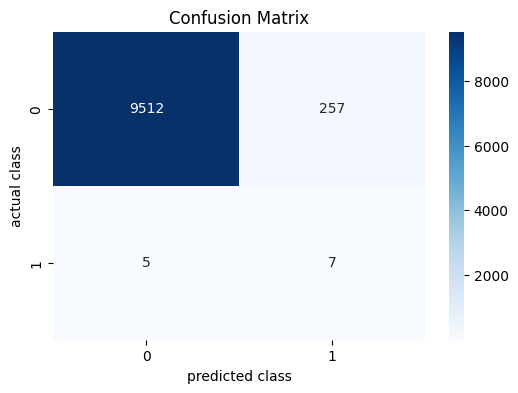

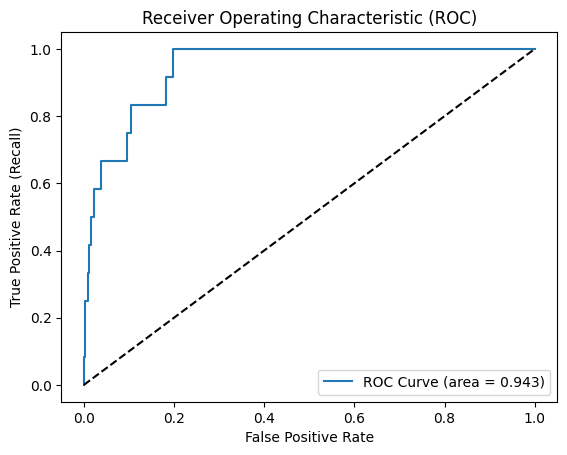

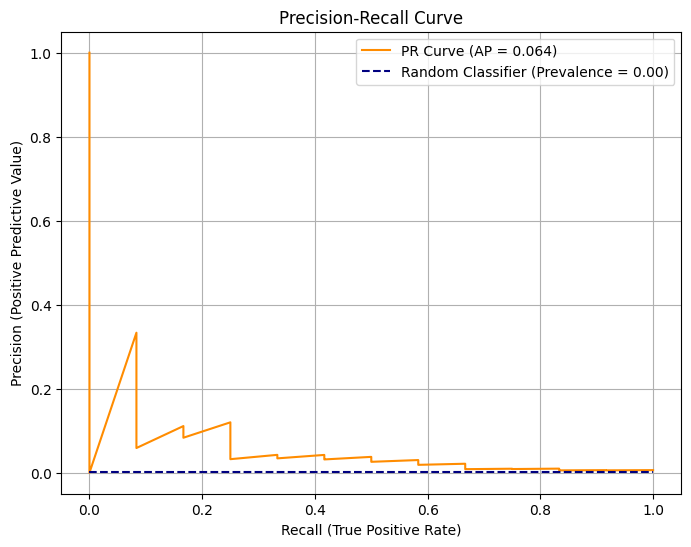

Average Precision (AP) Score: 0.064


In [46]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_D.predict(X_test_selected_2)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_10 = loaded_model_D.predict_proba(X_test_selected_2)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_10)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_10)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_10)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_10)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>XGB</h4>

In [17]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'feature_selection_xgb_xgb_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_D = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 feature_selection_xgb_xgb_model.joblib 載入。


準確度: 0.9988753706165013
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.55      0.50      0.52        12

    accuracy                           1.00      9781
   macro avg       0.77      0.75      0.76      9781
weighted avg       1.00      1.00      1.00      9781



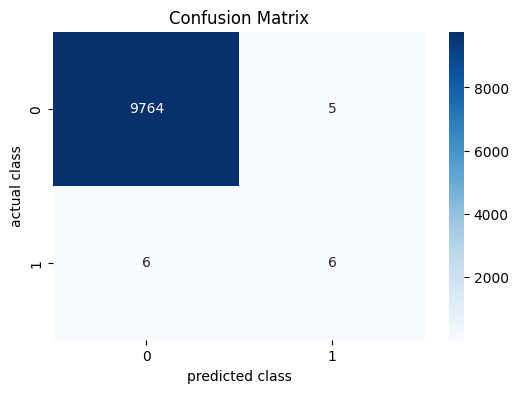

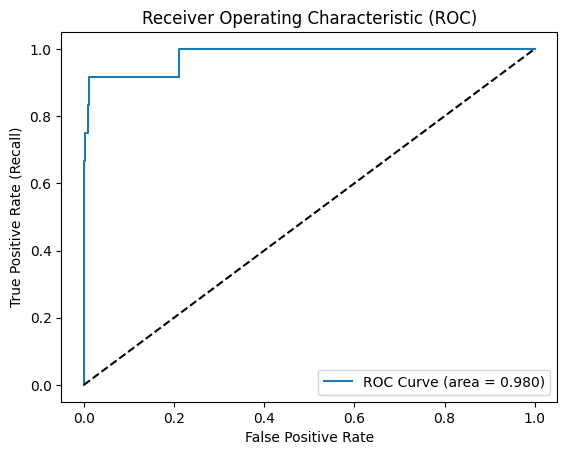

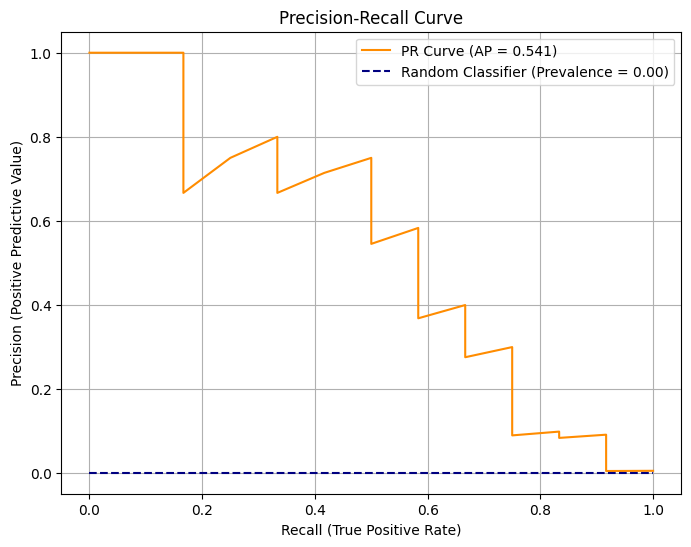

Average Precision (AP) Score: 0.541


In [18]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_D.predict(X_test_selected_2)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_11 = loaded_model_D.predict_proba(X_test_selected_2)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_11)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_11)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_11)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_11)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>SVM</h4>

In [29]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'feature_selection_xgb_svm_model.joblib'
# feature_selection_xgb_svm_model.joblib
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_D = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 feature_selection_xgb_svm_model.joblib 載入。


準確度: 0.9919231162457827
分類報告:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      9769
           1       0.10      0.67      0.17        12

    accuracy                           0.99      9781
   macro avg       0.55      0.83      0.58      9781
weighted avg       1.00      0.99      0.99      9781



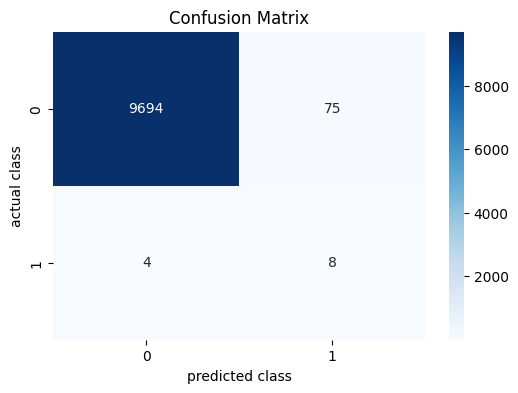

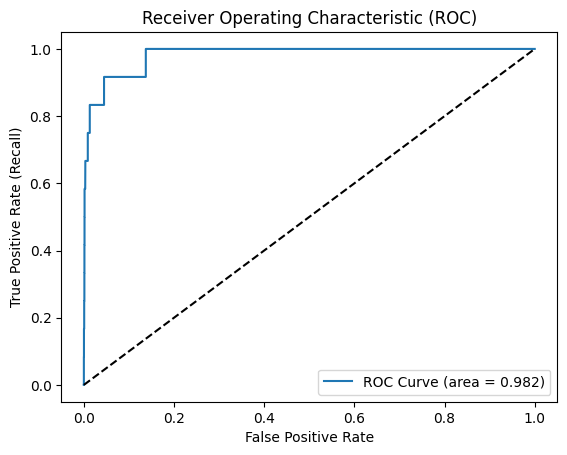

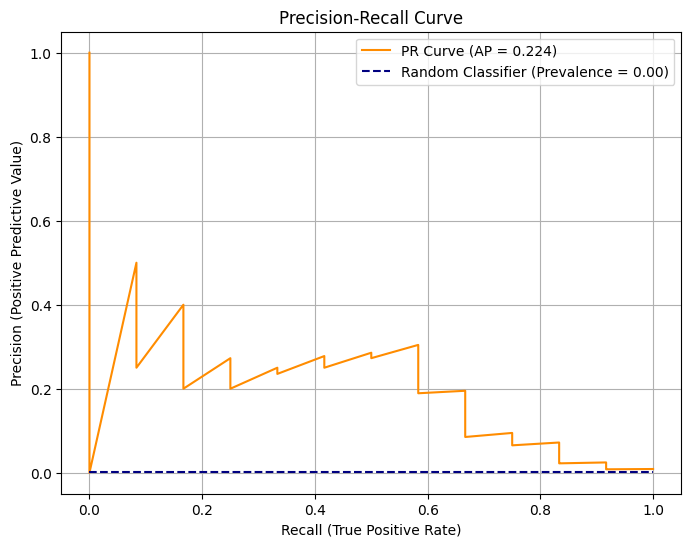

Average Precision (AP) Score: 0.224


In [30]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_D.predict(X_test_selected_2)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_12 = loaded_model_D.predict_proba(X_test_selected_2)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_12)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_12)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_12)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_12)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

<h4>RF</h4>

In [35]:
import joblib
# 定義儲存檔案的路徑和名稱（必須與儲存時的路徑一致或可達）
model_filename = 'feature_selection_xgb_rf_model.joblib'
# --- 重新載入模型和插補器 ---
print("\n--- 重新載入模型 ---")
# 載入模型
loaded_model_D = joblib.load(model_filename)
print(f"模型已從 {model_filename} 載入。")


--- 重新載入模型 ---
模型已從 feature_selection_xgb_rf_model.joblib 載入。


準確度: 0.9981596973724568
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.25      0.25      0.25        12

    accuracy                           1.00      9781
   macro avg       0.62      0.62      0.62      9781
weighted avg       1.00      1.00      1.00      9781



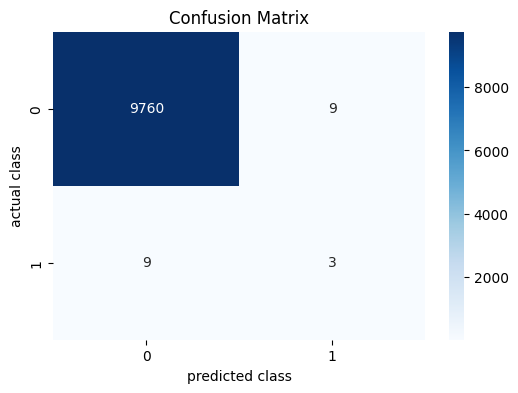

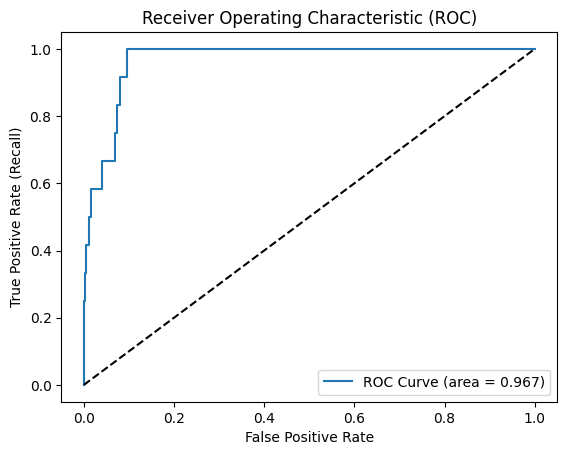

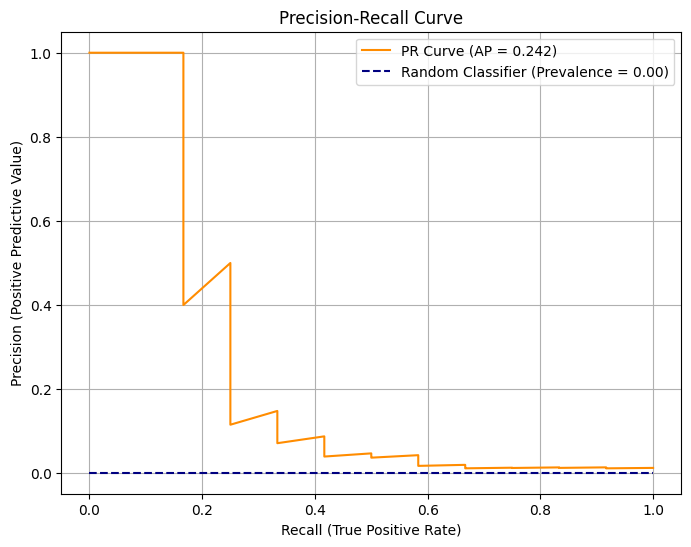

Average Precision (AP) Score: 0.242


In [36]:
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測
y_pred = loaded_model_D.predict(X_test_selected_2)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

# 預測概率（用於AUC）
y_pred_proba_13 = loaded_model_D.predict_proba(X_test_selected_2)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba_13)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_13)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_13)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba_13)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')

plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

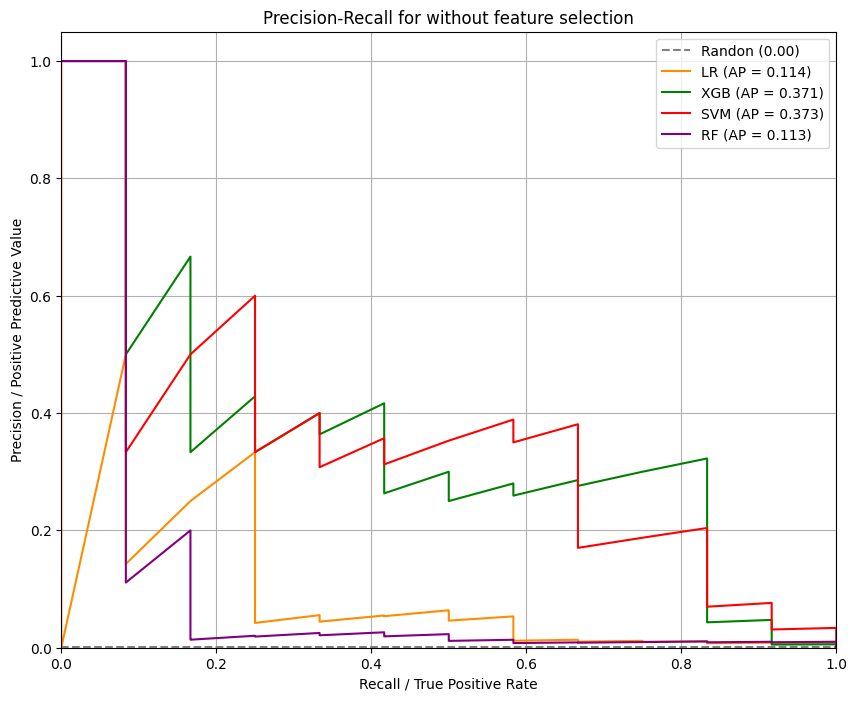

In [174]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np # 僅用於模擬數據，實際應用中您會使用模型預測結果

# --- 假設您有多個模型的預測結果 ---
# 這裡我們模擬了四個模型的 y_pred_proba。
# 在您的實際應用中，這些將是您不同模型對相同 X_test_scaled 進行 predict_proba() 的結果。


# 將所有模型的結果組織起來
# 每個元組包含 (模型名稱, 模型的 y_pred_proba)
model_results = [
    ('LR', y_pred_proba_2),
    ('XGB', y_pred_proba_3),
    ('SVM', y_pred_proba_4),
    ('RF', y_pred_proba_5),
]

# --- 初始化繪圖 ---
plt.figure(figsize=(10, 8))

# 繪製隨機分類器的基準線 (No-skill baseline)
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence],
         linestyle='--', color='gray', label=f'Randon ({no_skill_prevalence:.2f})')

# 為每個模型繪製 PR 曲線
colors = ['darkorange', 'green', 'red', 'purple', 'brown', 'cyan', 'magenta'] # 準備一些顏色
for i, (model_name, y_pred_proba) in enumerate(model_results):
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    ap_score = average_precision_score(y_test, y_pred_proba)
    plt.plot(recall, precision, color=colors[i % len(colors)], # 使用不同的顏色
             label=f'{model_name} (AP = {ap_score:.3f})') # 為每個模型設置唯一的標籤

# --- 設定圖表屬性 ---
plt.xlabel('Recall / True Positive Rate')
plt.ylabel('Precision / Positive Predictive Value')
plt.title('Precision-Recall for without feature selection')
plt.legend(loc='best') # 放置圖例在最佳位置，以區分不同模型
plt.grid(True) # 顯示網格
plt.ylim([0.0, 1.05]) # 設定 Y 軸範圍，通常從 0 到 1
plt.xlim([0.0, 1.0])  # 設定 X 軸範圍，通常從 0 到 1
plt.show()


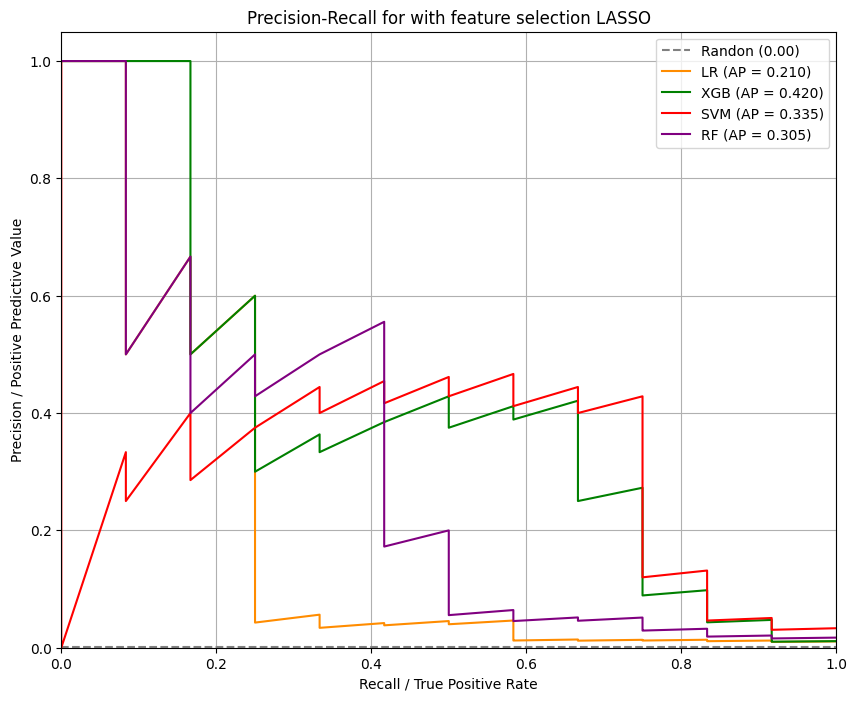

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np # 僅用於模擬數據，實際應用中您會使用模型預測結果

# --- 假設您有多個模型的預測結果 ---
# 這裡我們模擬了四個模型的 y_pred_proba。
# 在您的實際應用中，這些將是您不同模型對相同 X_test_scaled 進行 predict_proba() 的結果。


# 將所有模型的結果組織起來
# 每個元組包含 (模型名稱, 模型的 y_pred_proba)
model_results = [
    ('LR', y_pred_proba_6),
    ('XGB', y_pred_proba_7),
    ('SVM', y_pred_proba_8),
    ('RF', y_pred_proba_9),
]

# --- 初始化繪圖 ---
plt.figure(figsize=(10, 8))

# 繪製隨機分類器的基準線 (No-skill baseline)
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence],
         linestyle='--', color='gray', label=f'Randon ({no_skill_prevalence:.2f})')

# 為每個模型繪製 PR 曲線
colors = ['darkorange', 'green', 'red', 'purple', 'brown', 'cyan', 'magenta'] # 準備一些顏色
for i, (model_name, y_pred_proba) in enumerate(model_results):
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    ap_score = average_precision_score(y_test, y_pred_proba)
    plt.plot(recall, precision, color=colors[i % len(colors)], # 使用不同的顏色
             label=f'{model_name} (AP = {ap_score:.3f})') # 為每個模型設置唯一的標籤

# --- 設定圖表屬性 ---
plt.xlabel('Recall / True Positive Rate')
plt.ylabel('Precision / Positive Predictive Value')
plt.title('Precision-Recall for with feature selection LASSO')
plt.legend(loc='best') # 放置圖例在最佳位置，以區分不同模型
plt.grid(True) # 顯示網格
plt.ylim([0.0, 1.05]) # 設定 Y 軸範圍，通常從 0 到 1
plt.xlim([0.0, 1.0])  # 設定 X 軸範圍，通常從 0 到 1
plt.show()


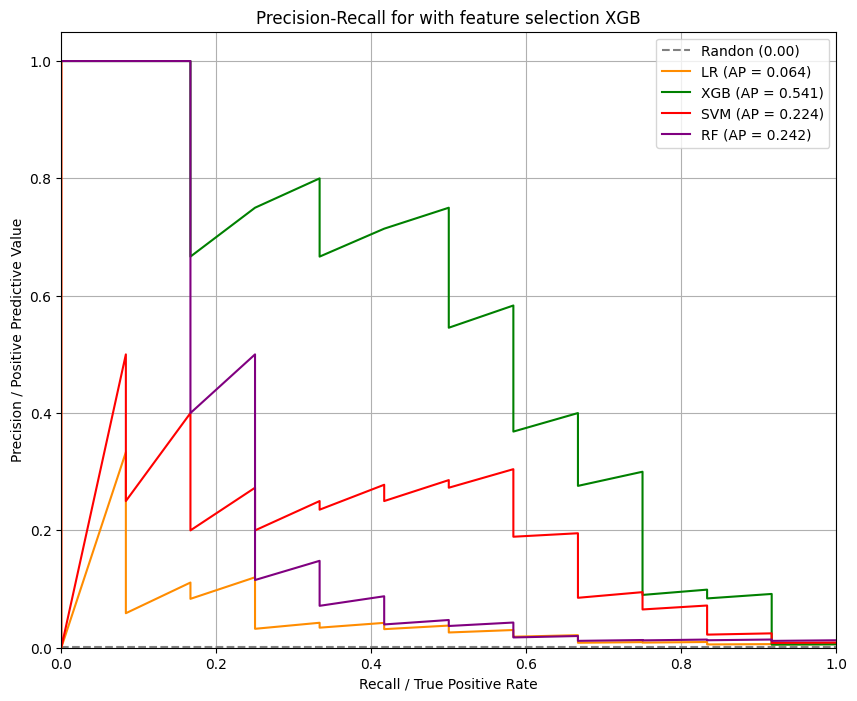

In [72]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np # 僅用於模擬數據，實際應用中您會使用模型預測結果

# --- 假設您有多個模型的預測結果 ---
# 這裡我們模擬了四個模型的 y_pred_proba。
# 在您的實際應用中，這些將是您不同模型對相同 X_test_scaled 進行 predict_proba() 的結果。


# 將所有模型的結果組織起來
# 每個元組包含 (模型名稱, 模型的 y_pred_proba)
model_results = [
    ('LR', y_pred_proba_10),
    ('XGB', y_pred_proba_11),
    ('SVM', y_pred_proba_12),
    ('RF', y_pred_proba_13),
]

# --- 初始化繪圖 ---
plt.figure(figsize=(10, 8))

# 繪製隨機分類器的基準線 (No-skill baseline)
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence],
         linestyle='--', color='gray', label=f'Randon ({no_skill_prevalence:.2f})')

# 為每個模型繪製 PR 曲線
colors = ['darkorange', 'green', 'red', 'purple', 'brown', 'cyan', 'magenta'] # 準備一些顏色
for i, (model_name, y_pred_proba) in enumerate(model_results):
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    ap_score = average_precision_score(y_test, y_pred_proba)
    plt.plot(recall, precision, color=colors[i % len(colors)], # 使用不同的顏色
             label=f'{model_name} (AP = {ap_score:.3f})') # 為每個模型設置唯一的標籤

# --- 設定圖表屬性 ---
plt.xlabel('Recall / True Positive Rate')
plt.ylabel('Precision / Positive Predictive Value')
plt.title('Precision-Recall for with feature selection XGB')
plt.legend(loc='best') # 放置圖例在最佳位置，以區分不同模型
plt.grid(True) # 顯示網格
plt.ylim([0.0, 1.05]) # 設定 Y 軸範圍，通常從 0 到 1
plt.xlim([0.0, 1.0])  # 設定 X 軸範圍，通常從 0 到 1
plt.show()
